In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

In [5]:
df = pd.read_csv("metadata.csv")
test_df = df.copy()

In [6]:
# 크기 확인
df.shape

(7565, 10)

In [7]:
# 컬럼 확인
test_df.columns

Index(['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id',
       'uid', 'filename', 'Capacity', 'Re', 'Rct'],
      dtype='str')

In [8]:
# 전반적인 구조와 결측치 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB


In [9]:
# 컬럼당 고유값 개수
test_df.nunique()

type                      3
start_time             2494
ambient_temperature       5
battery_id               34
test_id                 616
uid                    7565
filename               7565
Capacity               2752
Re                     1956
Rct                    1956
dtype: int64

In [ ]:
# 배터리 ID 개수
test_df['battery_id'].value_counts()

battery_id
B0006    616
B0005    616
B0007    616
B0034    486
B0033    486
B0036    486
B0018    319
B0043    275
B0042    275
B0044    275
B0054    253
B0056    252
B0055    252
B0047    184
B0045    184
B0048    184
B0046    184
B0041    163
B0053    137
B0039    122
B0040    122
B0038    122
B0032     97
B0029     97
B0030     97
B0031     97
B0028     80
B0027     80
B0025     80
B0026     80
B0049     62
B0050     62
B0052     62
B0051     62
Name: count, dtype: int64

In [ ]:
# 배터리 ID 비율 
test_df['battery_id'].value_counts(normalize=True)

battery_id
B0006    0.081428
B0005    0.081428
B0007    0.081428
B0034    0.064243
B0033    0.064243
B0036    0.064243
B0018    0.042168
B0043    0.036352
B0042    0.036352
B0044    0.036352
B0054    0.033443
B0056    0.033311
B0055    0.033311
B0047    0.024323
B0045    0.024323
B0048    0.024323
B0046    0.024323
B0041    0.021547
B0053    0.018110
B0039    0.016127
B0040    0.016127
B0038    0.016127
B0032    0.012822
B0029    0.012822
B0030    0.012822
B0031    0.012822
B0028    0.010575
B0027    0.010575
B0025    0.010575
B0026    0.010575
B0049    0.008196
B0050    0.008196
B0052    0.008196
B0051    0.008196
Name: proportion, dtype: float64

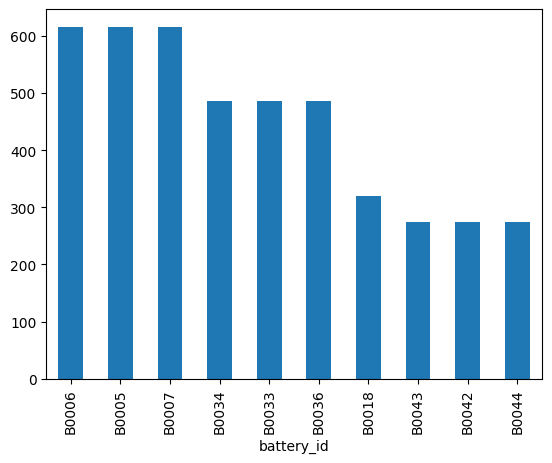

In [ ]:
import matplotlib.pyplot as plt

# 배터리 ID 상위 10개 막대 그래프
test_df['battery_id'].value_counts().head(10).plot(kind='bar')
plt.show()

In [ ]:
# 수치 데이터 요약
df.describe()
# ambiend_temperature만 의미가 있겠다..ㅋㅋㅋ

,ambient_temperature,test_id,uid
count,7565.000000,7565.000000,7565.000000
mean,20.017713,176.012558,3783.000000
std,11.082914,152.174147,2183.971726
min,4.000000,0.000000,1.000000
25%,4.000000,55.000000,1892.000000
50%,24.000000,129.000000,3783.000000
75%,24.000000,255.000000,5674.000000
max,44.000000,615.000000,7565.000000


In [12]:
# 결측치 개수 상세 확인
df.isnull().sum()

type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64

In [13]:
# 중복 데이터 확인
df.duplicated().sum()

np.int64(0)

In [14]:
test_df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [15]:
test_df.tail()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN
7564,charge,[2010. 9. 30. 12. 31. ...,4,B0055,251,7565,07565.csv,NaN,NaN,NaN


In [23]:
# start_time 확인
test_df['start_time'].value_counts()

start_time
[2010.       7.      21.      15.       0.      35.093]                4
[2010.       7.      21.      16.      53.      45.968]                4
[2010.       7.      21.      17.      25.      40.671]                4
[2010    7   21   20   31    5]                                        4
[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2.0000e+00 5.6984e+01]    4
                                                                      ..
[2.0080e+03 8.0000e+00 2.0000e+01 1.0000e+00 3.4000e+01 4.4437e+01]    1
[2.0080e+03 8.0000e+00 2.0000e+01 2.0000e+00 6.0000e+00 3.7718e+01]    1
[2.008e+03 8.000e+00 2.000e+01 5.000e+00 2.000e+00 2.960e-01]          1
[2008.       8.      20.       5.      49.      31.828]                1
[2008.       8.      20.       8.      37.      19.515]                1
Name: count, Length: 2494, dtype: int64

In [24]:
# 중복된 값과 그 횟수 확인
top_duplicated = test_df['Capacity'].value_counts()
print(top_duplicated[top_duplicated > 1].head(10))

Capacity
[]    25
0     19
Name: count, dtype: int64


In [25]:
# Capacity가 중복된 모든 행 추출 (원본 데이터 확인)
duplicated_rows = test_df[test_df.duplicated(subset=['Capacity'], keep=False)]

# 값이 같은 것끼리 모아서 정렬해보기
duplicated_rows.sort_values(by='Capacity').head(10)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
50,discharge,[2.0100e+03 7.0000e+00 2.9000e+01 2.0000e+00 1...,4,B0047,50,51,00051.csv,0,NaN,NaN
4482,discharge,[2010. 8. 28. 12. 33. ...,4,B0051,40,4483,04483.csv,0,NaN,NaN
6807,discharge,[2010. 9. 30. 15. 32. ...,4,B0053,136,6808,06808.csv,0,NaN,NaN
4358,discharge,[2010. 8. 28. 12. 33. ...,4,B0050,40,4359,04359.csv,0,NaN,NaN
4296,discharge,[2010. 8. 28. 12. 33. ...,4,B0049,40,4297,04297.csv,0,NaN,NaN
3252,discharge,[2010. 6. 4. 17. 26. 7.75],22,B0044,14,3253,03253.csv,0,NaN,NaN
1543,discharge,[2010. 6. 4. 17. 26. 7.75],22,B0042,14,1544,01544.csv,0,NaN,NaN
750,discharge,[2010. 6. 4. 17. 26. 7.75],22,B0043,14,751,00751.csv,0,NaN,NaN
716,discharge,[2010. 8. 13. 11. 16. ...,4,B0046,164,717,00717.csv,0,NaN,NaN
7060,discharge,[2010. 9. 30. 15. 32. ...,4,B0054,252,7061,07061.csv,0,NaN,NaN
